In [3]:
from google.colab import files
uploaded = files.upload()

Saving defi_funnel_dataset_v2.csv to defi_funnel_dataset_v2.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("defi_funnel_dataset_v2.csv")
df

,user_id,signup_date,country,device,user_segment,wallet_connected,funded,used_product,retained,deposit_amount
0,1,03.02.2024,DE,mobile,new,1.0,1,0,0,3699.28
1,2,03.06.2024,SG,mobile,returning,1.0,1,0,0,3513.58
2,3,2024-05-31,US,mobile,new,1.0,1,1,1,1269.04
3,4,2024-03-20,DE,desktop,new,1.0,1,0,0,4521.87
4,5,2024-05-19,AU,mobile,new,1.0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...
4995,4996,2024-01-28,NL,mobile,new,1.0,1,0,0,3300.28
4996,4997,03.06.2024,AU,mobile,new,1.0,0,0,0,0.00
4997,4998,04.07.2024,AU,mobile,returning,1.0,0,0,0,0.00
4998,4999,2024-02-29,US,desktop,returning,1.0,1,0,0,4598.32


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   signup_date       5000 non-null   object 
 2   country           5000 non-null   object 
 3   device            5000 non-null   object 
 4   user_segment      5000 non-null   object 
 5   wallet_connected  5000 non-null   float64
 6   funded            5000 non-null   int64  
 7   used_product      5000 non-null   int64  
 8   retained          5000 non-null   int64  
 9   deposit_amount    5000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 390.8+ KB


In [6]:
df.describe()

,user_id,wallet_connected,funded,used_product,retained,deposit_amount
count,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,1.0,0.645800,0.276000,0.135000,1634.931312
std,1443.520003,0.0,0.478318,0.447061,0.341758,1671.115094
min,1.000000,1.0,0.000000,0.000000,0.000000,0.000000
25%,1250.750000,1.0,0.000000,0.000000,0.000000,0.000000
50%,2500.500000,1.0,1.000000,0.000000,0.000000,1170.585000
75%,3750.250000,1.0,1.000000,1.000000,0.000000,3085.150000
max,5000.000000,1.0,1.000000,1.000000,1.000000,4998.380000


In [7]:
def parse_date(x):
    if '-' in x and x[:4].isdigit():
        return pd.to_datetime(x, format='%Y-%m-%d', errors='coerce')
    else:
        return pd.to_datetime(x, dayfirst=True, errors='coerce')

df['signup_date'] = df['signup_date'].apply(parse_date)

In [8]:
df.head()

,user_id,signup_date,country,device,user_segment,wallet_connected,funded,used_product,retained,deposit_amount
0,1,2024-02-03,DE,mobile,new,1.0,1,0,0,3699.28
1,2,2024-06-03,SG,mobile,returning,1.0,1,0,0,3513.58
2,3,2024-05-31,US,mobile,new,1.0,1,1,1,1269.04
3,4,2024-03-20,DE,desktop,new,1.0,1,0,0,4521.87
4,5,2024-05-19,AU,mobile,new,1.0,0,0,0,0.00


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   signup_date       5000 non-null   datetime64[ns]
 2   country           5000 non-null   object        
 3   device            5000 non-null   object        
 4   user_segment      5000 non-null   object        
 5   wallet_connected  5000 non-null   float64       
 6   funded            5000 non-null   int64         
 7   used_product      5000 non-null   int64         
 8   retained          5000 non-null   int64         
 9   deposit_amount    5000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 390.8+ KB


In [10]:
total = len(df)
funded = df['funded'].sum()
used = df['used_product'].sum()
retained = df['retained'].sum()

print(total, funded, used, retained)

5000 3229 1380 675


In [11]:
funded_rate = funded / total
usage_rate = used / funded
retention_rate = retained / used

print(funded_rate, usage_rate, retention_rate)

0.6458 0.4273768968720966 0.4891304347826087


In [12]:
funnel = pd.DataFrame({
    'Stage': ['Connected', 'Funded', 'Used', 'Retained'],
    'Users': [len(df), df['funded'].sum(), df['used_product'].sum(), df['retained'].sum()]
})

funnel['Conversion'] = funnel['Users'] / funnel['Users'].shift(1)
print(funnel)

       Stage  Users  Conversion
0  Connected   5000         NaN
1     Funded   3229    0.645800
2       Used   1380    0.427377
3   Retained    675    0.489130


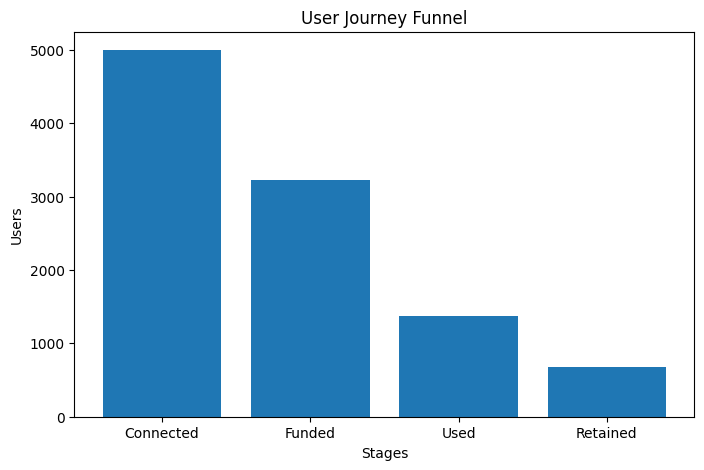

In [13]:
import matplotlib.pyplot as plt

stages = ['Connected', 'Funded', 'Used', 'Retained']
values = [total, funded, used, retained]

plt.figure(figsize=(8,5))
plt.bar(stages, values)
plt.title("User Journey Funnel")
plt.xlabel("Stages")
plt.ylabel("Users")
plt.show()

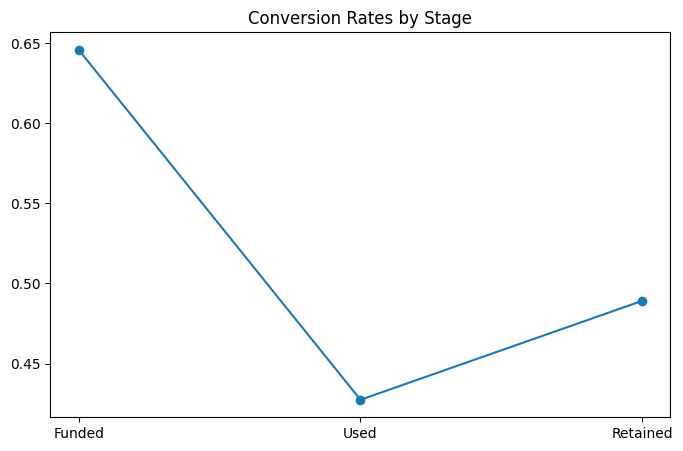

In [14]:
plt.figure(figsize=(8,5))
plt.plot(funnel['Stage'], funnel['Conversion'], marker='o')
plt.title("Conversion Rates by Stage")
plt.show()

In [15]:
df.groupby('country')['funded'].mean().sort_values(ascending=False)


,funded
country,
SG,0.664107
US,0.659406
FR,0.658487
IT,0.656379
NL,0.648889
CA,0.645291
DE,0.640404
UK,0.638623
AU,0.627680


In [16]:
df.device.value_counts()

,count
device,
mobile,2921
desktop,1550
tablet,529


In [17]:
df.groupby(['country','device'])['used_product'].mean()

country  device 
AU       desktop    0.215686
         mobile     0.245791
         tablet     0.333333
CA       desktop    0.322581
         mobile     0.286738
         tablet     0.323077
DE       desktop    0.315068
         mobile     0.275168
         tablet     0.176471
ES       desktop    0.209459
         mobile     0.254658
         tablet     0.326531
FR       desktop    0.273885
         mobile     0.312950
         tablet     0.296296
IT       desktop    0.271605
         mobile     0.255973
         tablet     0.419355
NL       desktop    0.306122
         mobile     0.263566
         tablet     0.244444
SG       desktop    0.215686
         mobile     0.306189
         tablet     0.360656
UK       desktop    0.237500
         mobile     0.260317
         tablet     0.250000
US       desktop    0.295858
         mobile     0.299270
         tablet     0.338710
Name: used_product, dtype: float64

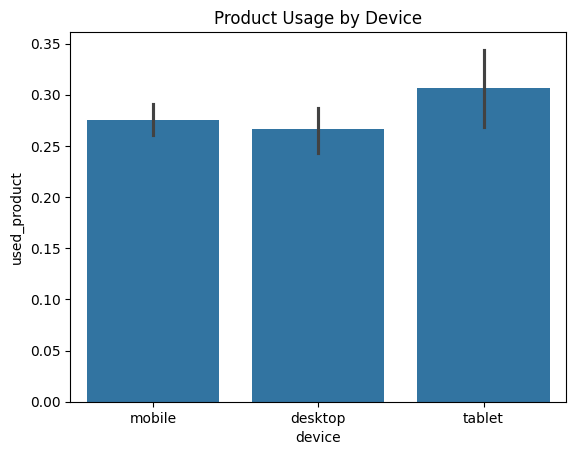

In [19]:
sns.barplot(x='device', y='used_product', data=df)
plt.title("Product Usage by Device")
plt.show()

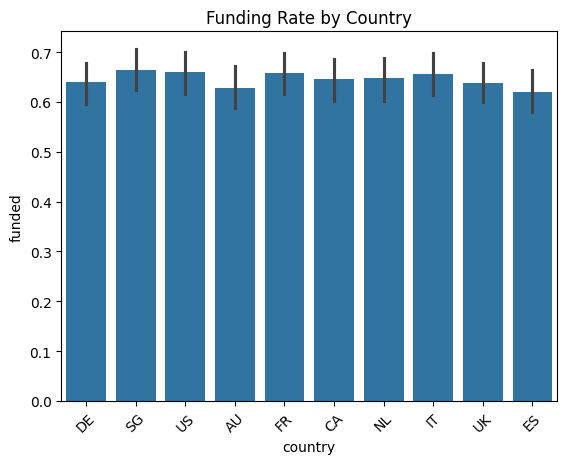

In [20]:
sns.barplot(x='country', y='funded', data=df)
plt.title("Funding Rate by Country")
plt.xticks(rotation=45)
plt.show()

In [113]:
df.to_csv("clean_data.csv", index=False)

In [65]:
df_filtered = df[df['deposit_amount'] > 0]

result = df_filtered.groupby('country')['deposit_amount'].agg(['sum', 'mean', 'median', 'min', 'max'])

result

,sum,mean,median,min,max
country,,,,,
AU,801647.70,2489.589130,2432.795,106.59,4996.71
CA,787939.07,2447.015745,2386.565,62.15,4997.55
DE,816325.32,2575.158738,2447.500,65.45,4993.56
ES,819420.83,2544.785186,2569.550,62.51,4980.92
FR,839141.17,2606.028478,2775.890,50.78,4991.62
IT,792857.17,2485.445674,2415.560,55.96,4998.38
NL,764933.98,2619.636918,2789.030,69.45,4960.39
SG,882432.54,2550.383064,2464.755,54.67,4977.81
UK,809492.92,2423.631497,2346.250,51.19,4958.78


In [77]:
df[df['deposit_amount'] > 0]['deposit_amount'].min()

50.78

In [59]:
df[df['deposit_amount'].agg(['mean', 'median', 'min', 'max'])

,deposit_amount
mean,1634.931312
median,1170.585000
min,0.000000
max,4998.380000


In [57]:
df[df['deposit_amount'] > 0]['deposit_amount'].agg(['mean', 'median', 'min', 'max'])

,deposit_amount
mean,2531.637213
median,2515.850000
min,50.780000
max,4998.380000
